In [6]:
# ── IMPORTS ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── LOAD PROCESSED DATA ───────────────────────────────────
X_train = pd.read_csv("../data/X_train_processed.csv")
X_val = pd.read_csv("../data/X_val_processed.csv")
X_test = pd.read_csv("../data/X_test_processed.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1227, 218)
X_val shape: (217, 218)
X_test shape: (1459, 218)


In [7]:
# ── APPROACH 1: DROP HIGHLY CORRELATED FEATURES ───────────
# If two features correlate > 0.85 with each other
# they carry almost the same info — keep the one
# that correlates more strongly with target

corr_matrix = X_train.corr().abs()

# get upper triangle only (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85
cols_to_drop = []

for col in upper.columns:
    for idx in upper.index:
        if upper.loc[idx, col] > threshold:
            # keep whichever correlates more with target
            corr_f1 = abs(X_train[idx].corr(y_train))
            corr_f2 = abs(X_train[col].corr(y_train))
            drop = idx if corr_f1 < corr_f2 else col
            cols_to_drop.append(drop)

cols_to_drop = list(set(cols_to_drop))
print(f"Dropping {len(cols_to_drop)} correlated features:")
print(cols_to_drop)

X_train_corr = X_train.drop(columns=cols_to_drop)
X_val_corr = X_val.drop(columns=cols_to_drop)
X_test_corr = X_test.drop(columns=cols_to_drop)

print(f"\nShape after correlation drop: {X_train_corr.shape}")

Dropping 22 correlated features:
['SaleCondition_Partial', 'MSSubClass_45', 'Exterior2nd_CBlock', 'Fireplaces', 'RoofStyle_Hip', 'YearBuilt', 'MSSubClass_90', 'Exterior2nd_Wd Sdng', 'MSSubClass_50', 'Exterior1st_VinylSd', 'HasBasement', 'YearRemodAdd', 'GrLivArea', 'HasGarage', 'HasFireplace', 'MSSubClass_80', 'Exterior1st_CemntBd', 'GarageArea', 'Exterior2nd_HdBoard', 'MSSubClass_190', 'Exterior2nd_MetalSd', 'CentralAir_Y']

Shape after correlation drop: (1227, 196)


In [8]:
# ── APPROACH 2: DROP LOW VARIANCE FEATURES ────────────────
# Features where almost every house has the same value
# are useless — they can't help distinguish prices
# e.g. a column that is 0 for 99% of houses tells us nothing

from sklearn.feature_selection import VarianceThreshold

# threshold=0.01 means drop features where variance < 0.01
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

# get which columns to keep
kept_mask = selector.get_support()
kept_cols = X_train.columns[kept_mask].tolist()
dropped_cols = X_train.columns[~kept_mask].tolist()

print(f"Dropped {len(dropped_cols)} low variance features:")
print(dropped_cols)
print(f"\nKept {len(kept_cols)} features")

X_train_var = X_train[kept_cols]
X_val_var = X_val[kept_cols]
X_test_var = X_test[kept_cols]

print(f"Shape after variance drop: {X_train_var.shape}")

Dropped 44 low variance features:
['MSZoning_C (all)', 'LotConfig_FR3', 'Neighborhood_Veenker', 'Neighborhood_NPkVill', 'Neighborhood_Blueste', 'Condition1_RRAe', 'Condition1_RRNn', 'Condition1_PosA', 'Condition1_RRNe', 'HouseStyle_2.5Unf', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Fin', 'RoofStyle_Gambrel', 'RoofStyle_Flat', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'Exterior1st_CBlock', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_Stone', 'Exterior1st_ImStucc', 'Exterior2nd_ImStucc', 'Exterior2nd_CBlock', 'Exterior2nd_Other', 'Exterior2nd_Stone', 'Exterior2nd_AsphShn', 'Exterior2nd_Brk Cmn', 'Foundation_Stone', 'Foundation_Wood', 'Electrical_FuseP', 'GarageType_2Types', 'GarageType_CarPort', 'SaleType_ConLD', 'SaleType_CWD', 'SaleType_ConLI', 'SaleType_Oth', 'SaleType_ConLw', 'SaleType_Con', 'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'MSSubClass_75', 'MSSubClass_45', 'MSSubClass_180', 'MSSubClass_40']

Kept 174 features
Shape after variance drop: (1227, 174)


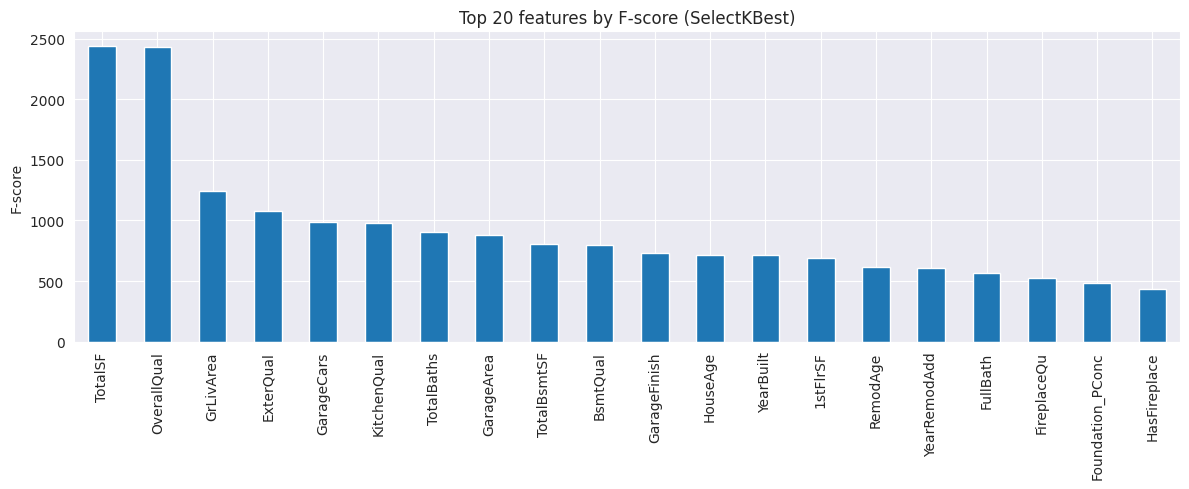

Shape after SelectKBest: (1227, 100)


In [9]:
# ── APPROACH 3: SELECTKBEST ───────────────────────────────
# Statistically scores each feature's relationship with target
# Keeps only the top K most informative features
# Uses f_regression which measures linear correlation strength

from sklearn.feature_selection import SelectKBest, f_regression

K = 100  # keep top 100 features

selector_kbest = SelectKBest(score_func=f_regression, k=K)
selector_kbest.fit(X_train, y_train)

# get selected feature names
kbest_mask = selector_kbest.get_support()
kbest_cols = X_train.columns[kbest_mask].tolist()

# visualize top 20 scores
scores = pd.Series(selector_kbest.scores_, index=X_train.columns)
scores = scores.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
scores.head(20).plot(kind="bar")
plt.title("Top 20 features by F-score (SelectKBest)")
plt.ylabel("F-score")
plt.tight_layout()
plt.show()

X_train_kbest = X_train[kbest_cols]
X_val_kbest = X_val[kbest_cols]
X_test_kbest = X_test[kbest_cols]

print(f"Shape after SelectKBest: {X_train_kbest.shape}")

In [13]:
# approach 4: RFE (recursive feature elimination)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor  # or LinearRegression

# Estimator (tree-based or linear)
estimator = Ridge(0.07)

# Number of features to select
n_features_to_select = 150

# RFE wrapper
selector_rfe = RFE(estimator=estimator, n_features_to_select=n_features_to_select, step=10)  # step=10 removes 10 features per iteration
selector_rfe.fit(X_train, y_train)
rfe_mask = selector_rfe.get_support()
rfe_cols = X_train.columns[rfe_mask].tolist()
print(f"Selected {len(rfe_cols)} features with RFE")

X_train_rfe = X_train[rfe_cols]
X_val_rfe = X_val[rfe_cols]
X_test_rfe = X_test[rfe_cols]

print("Shapes after RFE:")
print(X_train_rfe.shape, X_val_rfe.shape, X_test_rfe.shape)

Selected 150 features with RFE
Shapes after RFE:
(1227, 150) (217, 150) (1459, 150)


In [11]:
# mix of all the above method
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

def full_feature_selection(X_train, y_train, X_val, X_test,
                           corr_thresh=0.85, var_thresh=0.01, kbest_k=150, rfe_n=100):
    X_train_fs = X_train.copy()
    X_val_fs = X_val.copy()
    X_test_fs = X_test.copy()

    # ── 1. Drop highly correlated features ─────────────────
    corr_matrix = X_train_fs.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    cols_to_drop_corr = []
    for col in upper.columns:
        for idx in upper.index:
            if upper.loc[idx, col] > corr_thresh:
                corr_f1 = abs(X_train_fs[idx].corr(y_train))
                corr_f2 = abs(X_train_fs[col].corr(y_train))
                drop = idx if corr_f1 < corr_f2 else col
                cols_to_drop_corr.append(drop)
    cols_to_drop_corr = list(set(cols_to_drop_corr))

    X_train_fs = X_train_fs.drop(columns=cols_to_drop_corr)
    X_val_fs = X_val_fs.drop(columns=cols_to_drop_corr)
    X_test_fs = X_test_fs.drop(columns=cols_to_drop_corr)
    print(f"Dropped {len(cols_to_drop_corr)} correlated features")

    # ── 2. Drop low variance features ────────────────────
    selector_var = VarianceThreshold(threshold=var_thresh)
    selector_var.fit(X_train_fs)

    kept_mask = selector_var.get_support()
    kept_cols = X_train_fs.columns[kept_mask].tolist()

    X_train_fs = X_train_fs[kept_cols]
    X_val_fs = X_val_fs[kept_cols]
    X_test_fs = X_test_fs[kept_cols]
    print(f"Kept {len(kept_cols)} features after low variance drop")

    # ── 3. SelectKBest ─────────────────────────────────
    selector_kbest = SelectKBest(score_func=f_regression, k=kbest_k)
    selector_kbest.fit(X_train_fs, y_train)

    kbest_mask = selector_kbest.get_support()
    kbest_cols = X_train_fs.columns[kbest_mask].tolist()

    X_train_fs = X_train_fs[kbest_cols]
    X_val_fs = X_val_fs[kbest_cols]
    X_test_fs = X_test_fs[kbest_cols]
    print(f"Kept {len(kbest_cols)} features after SelectKBest (k={kbest_k})")

    # ── 4. RFE ─────────────────────────────────────────
    estimator = RandomForestRegressor(n_estimators=100, random_state=42)
    selector_rfe = RFE(estimator=estimator, n_features_to_select=rfe_n, step=10)
    selector_rfe.fit(X_train_fs, y_train)

    rfe_mask = selector_rfe.get_support()
    rfe_cols = X_train_fs.columns[rfe_mask].tolist()

    X_train_fs = X_train_fs[rfe_cols]
    X_val_fs = X_val_fs[rfe_cols]
    X_test_fs = X_test_fs[rfe_cols]
    print(f"Selected {len(rfe_cols)} features with RFE (final)")

    return X_train_fs, X_val_fs, X_test_fs

X_train_final, X_val_final, X_test_final = full_feature_selection(
    X_train, y_train, X_val, X_test,
    corr_thresh=0.85, var_thresh=0.01, kbest_k=150, rfe_n=100
)


Dropped 22 correlated features
Kept 154 features after low variance drop
Kept 150 features after SelectKBest (k=150)
Selected 100 features with RFE (final)


In [14]:
# ── SUMMARY: COMPARE ALL APPROACHES ──────────────────────
print("Feature counts after each approach:")
print(f"  Original:              {X_train.shape[1]} features")
print(f"  Correlation drop:      {X_train_corr.shape[1]} features")
print(f"  Variance drop:         {X_train_var.shape[1]} features")
print(f"  SelectKBest (k=100):   {X_train_kbest.shape[1]} features")
print(f"  RFE (n=100):           {X_train_rfe.shape[1]} features")
print(f"  Full pipeline:          {X_train_final.shape[1]} features")

Feature counts after each approach:
  Original:              218 features
  Correlation drop:      196 features
  Variance drop:         174 features
  SelectKBest (k=100):   100 features
  RFE (n=100):           150 features
  Full pipeline:          100 features
